# Indicador I.2 - Areas protegidas con planes de manejo y área terrestre bajo gestión efectiva.

### 1) Lectura desde el origen web SIMBIO

- Se descarga el Catálogo Extendido desde la URL oficial.
- Si el archivo contiene **múltiples hojas**, se intentan identificar automáticamente:
  - Hoja **General** → información principal de las áreas protegidas.
  - Hoja **Instrumentos de Manejo** → información sobre planes e instrumentos de gestión.
  - Hoja **Ambiente** → variables ambientales asociadas.
- Se informa por consola:
  - Las hojas detectadas.
  - Qué hojas se están utilizando efectivamente.
- Si el archivo contiene una sola tabla, esta se asigna a `df_general` y se crean `DataFrame` vacíos para manejo y ambiente.

---

### Propósito general del script

El código está diseñado para ser un **punto de entrada reproducible y robusto** al Catálogo Extendido de Áreas Protegidas de SIMBIO, facilitando su integración en flujos de análisis posteriores (por ejemplo, evaluación de planes de manejo, indicadores de cobertura o gobernanza), incluso ante cambios en el formato del archivo publicado.




In [2]:
# ============================================================
# 0) Setup
# ============================================================
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

import io
import time
import requests

# Fuente oficial (Descargar -> Catálogo extendido)
EXCEL_EXTENDIDO_URL = "https://simbio.mma.gob.cl/CbaAP/GetExcelExtendido"

KEY = "Código AP"

# ------------------------------------------------------------
# Helper: descarga robusta + lectura (Excel o CSV desde URL)
# ------------------------------------------------------------
def fetch_bytes(url: str, timeout: int = 120, retries: int = 3, sleep_s: float = 2.0) -> bytes:
    headers = {
        # User-Agent ayuda con algunos servidores que bloquean requests "vacíos"
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
    }
    last_err = None
    for i in range(retries):
        try:
            r = requests.get(url, headers=headers, timeout=timeout, allow_redirects=True)
            r.raise_for_status()
            return r.content
        except Exception as e:
            last_err = e
            if i < retries - 1:
                time.sleep(sleep_s)
    raise RuntimeError(f"No se pudo descargar {url} tras {retries} intentos. Último error: {last_err}")

def read_table_from_url(url: str):
    data = fetch_bytes(url)
    # Intentar Excel primero (el endpoint se llama GetExcelExtendido)
    try:
        xls = pd.ExcelFile(io.BytesIO(data))
        sheets = xls.sheet_names
        if len(sheets) == 1:
            return pd.read_excel(xls, sheet_name=sheets[0])
        return {name: pd.read_excel(xls, sheet_name=name) for name in sheets}
    except Exception:
        # Fallback: intentar como CSV con separador inferido y encoding típico
        for enc in ("utf-8", "latin-1"):
            try:
                return pd.read_csv(io.BytesIO(data), sep=None, engine="python", encoding=enc)
            except UnicodeDecodeError:
                continue
        return pd.read_csv(io.BytesIO(data), encoding="latin-1")

def pick_sheet(dfs: dict, include: str):
    """Selecciona una hoja por substring (case-insensitive)."""
    include = include.lower()
    for k in dfs.keys():
        if include in k.lower():
            return dfs[k], k
    # fallback: primera hoja
    first = next(iter(dfs.items()))
    return first[1], first[0]

# ============================================================
# 1) Lectura desde origen web SIMBIO
# ============================================================
obj = read_table_from_url(EXCEL_EXTENDIDO_URL)

# Si viene como Excel con múltiples hojas, intentamos mapear a general/manejo
if isinstance(obj, dict):
    df_general, sh_general = pick_sheet(obj, "General")
    df_manejo,  sh_manejo  = pick_sheet(obj, "Instrumentos de Manejo")
    df_ambiente, sh_ambiente = pick_sheet(obj, "Ambiente")
    print(f"Hojas detectadas: {list(obj.keys())}")
    print(f"Usando hoja GENERAL: {sh_general}")
    print(f"Usando hoja MANEJO : {sh_manejo}")
else:
    # Si viene en una sola tabla, la dejamos como "general" y "manejo" queda vacío
    df_general = obj
    df_manejo  = pd.DataFrame()
    df_ambiente = pd.DataFrame()
    print("Se descargó una sola tabla (sin múltiples hojas).")

print("\nGeneral:", df_general.shape)
print("Manejo :", df_manejo.shape)

print("\nColumnas general:")
print(df_general.columns.tolist())

print("\nColumnas manejo:")
print(df_manejo.columns.tolist())



Hojas detectadas: ['General', 'Categoría de manejo (UICN)', 'Instrumentos de Manejo', 'Ambientes', 'Tipo Ecorregión', 'DPA', 'Cuencas', 'Historia legal', 'Ecosistemas terrestres', 'Ecosistemas marinos', 'Humedales', 'Especies', 'Servicios ecositémicos', 'Autoridad Usuario', 'Propiedad', 'Objetos de protección', 'Objetivos de protección', 'Amenaza o fuente de presiones', 'Uso de suelo', 'Planes RECOGE', 'Restauración ecológica']
Usando hoja GENERAL: General
Usando hoja MANEJO : Instrumentos de Manejo

General: (249, 17)
Manejo : (247, 5)

Columnas general:
['Código AP', 'Nombre original', 'Descripción', 'Categoría o designación', 'Tipo designación', 'Importancia', 'Superficie oficial', 'Superficie calculada', 'Fuente de información usada para indicar la superficie oficial', 'Año de inicio de la protección oficial', 'Estatus', 'Año estatus', 'Ambiente de gestión', 'Descripción objetos de protección', 'Descripción objetivos de protección', 'Descripción valores complementarios', 'Coordenad

In [3]:
# ============================================================
# 1) Validación y estandarización del KEY
# ============================================================

def normalize_key(series: pd.Series) -> pd.Series:
    # convierte a string, strip, y normaliza espacios raros
    s = series.astype(str).str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    # si hay cosas tipo 'nan' como texto, pásalas a NaN real
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s

for df, name in [(df_general, "general"), (df_manejo, "manejo")]:
    if KEY not in df.columns:
        raise KeyError(f"No encontré la columna '{KEY}' en {name}. Columnas: {df.columns.tolist()}")
    df[KEY] = normalize_key(df[KEY])

# Duplicados por KEY (importante: manejo podría traer 1:N; lo veremos)
dup_gen = df_general[df_general.duplicated(KEY, keep=False)].sort_values(KEY)
dup_man = df_manejo[df_manejo.duplicated(KEY, keep=False)].sort_values(KEY)

print("Duplicados en general:", len(dup_gen))
print("Duplicados en manejo :", len(dup_man))

# Si quieres inspeccionar duplicados:
# display(dup_gen.head(20))
# display(dup_man.head(20))


Duplicados en general: 0
Duplicados en manejo : 143


- Se imprimen:
  - El número total de registros originales en `df_manejo`.
  - El número de registros después del filtrado.
- Se muestra la frecuencia de cada categoría (`value_counts()`), lo que permite validar rápidamente que el filtrado se realizó correctamente.

---

### Propósito del bloque

Este bloque prepara los datos para análisis posteriores al:
- Garantizar una **clave limpia y consistente** para cruces entre tablas.
- Detectar problemas de **duplicación** tempranamente.
- Aislar únicamente la información relevante sobre **planes de manejo**, facilitando el cálculo de indicadores y métricas de gobernanza de áreas protegidas.


In [5]:
# ============================================================
# Filtrar df_manejo: solo Plan de Manejo o No Tiene
# ============================================================

# Normalizamos la columna Tipo por seguridad
df_manejo["Tipo"] = (
    df_manejo["Tipo"]
    .astype(str)
    .str.strip()
)

valores_validos = ["Plan de manejo", "No Tiene"]

df_manejo_filtrado = df_manejo[df_manejo["Tipo"].isin(valores_validos)].copy()

#print("Registros manejo (original):", len(df_manejo))
#print("Registros manejo (filtrado):", len(df_manejo_filtrado))

# Revisión rápida
#df_manejo_filtrado["Tipo"].value_counts()

tabla_resumen = (
    df_manejo_filtrado
    .groupby("Tipo", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

# Calcular porcentaje
total = tabla_resumen["n"].sum()
tabla_resumen["porcentaje"] = (tabla_resumen["n"] / total * 100).round(1)

tabla_resumen

,Tipo,n,porcentaje
0,No Tiene,36,24.8
1,Plan de manejo,109,75.2


In [10]:
# Agregar a nivel Código AP
manejo_agg = (
    df_manejo_filtrado
    .groupby(KEY, as_index=False)
    .agg(
        tiene_plan=("Tipo", lambda x: (x == "Plan de manejo").any()),
        tipo_plan=("Tipo", lambda x: "Plan de manejo" if (x == "Plan de manejo").any() else "No Tiene")
    )
)

manejo_agg.head()

,Código AP,tiene_plan,tipo_plan
0,WDPA-001,True,Plan de manejo
1,WDPA-002,False,No Tiene
2,WDPA-003,True,Plan de manejo
3,WDPA-004,True,Plan de manejo
4,WDPA-005,True,Plan de manejo


In [11]:
df = (
    df_general
    .merge(manejo_agg, on=KEY, how="left")
    .merge(df_ambiente, on=KEY, how="left")
)

# Si no aparece en manejo → No Tiene
df["tiene_plan"] = df["tiene_plan"].fillna(False)
df["tipo_plan"]  = df["tipo_plan"].fillna("No Tiene")

df.head()

,Código AP,Nombre original,Descripción,Categoría o designación,Tipo designación,Importancia,Superficie oficial,Superficie calculada,Fuente de información usada para indicar la superficie oficial,Año de inicio de la protección oficial,Estatus,Año estatus,Ambiente de gestión,Descripción objetos de protección,Descripción objetivos de protección,Descripción valores complementarios,Coordenada geográfica,tiene_plan,tipo_plan,Presencia,Procentaje del AP
0,WDPA-011,La Portada,"La unidad destaca por “La Portada”, una secuen...",Monumento Natural,Áreas Protegidas,Área conocida a nivel nacional e internacional...,31.0,NaN,Decreto de creación,1990,Designada,1990,NaN,Gran arco de La Portada (acantilado marino fós...,Preservar un rasgo geomorfológico de carácter ...,NaN,NaN,True,Plan de manejo,Terrestre,0.0
1,WDPA-015,Cerro Ñielol,El Monumento se ubica en el sector más austral...,Monumento Natural,Áreas Protegidas,Forma parte de uno de los sitios más australes...,90.0,NaN,Decreto de creación,1939,Designada,1987,NaN,Especies forestales (Decreto de 1949). Bosque ...,Conservar especies forestales naturales (decre...,NaN,NaN,True,Plan de manejo,Terrestre,0.0
2,WDPA-019,Cinco Hermanas,"El Monumento Natural Cinco Hermanas, correspon...",Monumento Natural,Áreas Protegidas,Se compone de seis pequeñas islas. La vegetaci...,228.0,NaN,Decreto de creación,1964,Designada,1982,NaN,"Flora, la Fauna y las Bellezas Escénicas (decr...",Proteger el bosque especialmente la formación ...,NaN,NaN,True,Plan de manejo,Terrestre,0.0
3,WDPA-016,Contulmo,"Esta área, destaca por la protección de las es...",Monumento Natural,Áreas Protegidas,Forma parte de la cordillera de Nahuelbuta y e...,82.0,NaN,Decreto de creación,1941,Designada,1982,NaN,Bosques relictos de altitudes bajas de la Cord...,"Conservación de flora y fauna (Plan de manejo,...",NaN,NaN,True,Plan de manejo,Terrestre,0.0
4,WDPA-023,Cueva del Milodón,Enorme caverna de más de 200 metros de profund...,Monumento Natural,Áreas Protegidas,En esta unidad podemos encontrar el bosque mag...,189.0,NaN,Decreto de creación,1993,Designada,1993,NaN,Recursos arqueológicos y geomorfológicos que e...,Conservar y proteger los importantes recursos ...,NaN,NaN,True,Plan de manejo,Terrestre,0.0


In [12]:
df["Presencia"].value_counts(dropna=False)

Presencia
Terrestre    172
Marino        49
Acuático      38
Name: count, dtype: int64

## Cálculo de la superficie de áreas protegidas con plan de manejo

Este bloque calcula la **superficie total de áreas protegidas (AP) con plan de manejo**, considerando únicamente aquellas con **presencia terrestre y/o acuática**, y estima su **porcentaje respecto del área continental de Chile**. Finalmente, organiza los resultados en una **tabla resumen**.

---

### Parámetros de referencia

- **Área continental de Chile (ha)**  
  Valor de referencia extraído del **Indicador A.1**.

```python
AREA_CHILE_CONTINENTAL = 75688051.58421065

In [14]:
# Área total de Chile continental (ha) extraído desde indicaddor A.1
AREA_CHILE_CONTINENTAL = 75688051.58421065

# Asegurar tipos
df["tiene_plan"] = df["tiene_plan"].astype(bool)
df["Superficie oficial"] = pd.to_numeric(
    df["Superficie oficial"], errors="coerce"
)

# Valores de Presencia a considerar
PRESENCIAS_VALIDAS = ["Terrestre", "Acuático"]

# 1) Suma de superficie oficial con plan y presencia válida
superficie_con_plan = (
    df
    .loc[
        (df["tiene_plan"]) &
        (df["Presencia"].isin(PRESENCIAS_VALIDAS)),
        "Superficie oficial"
    ]
    .sum(skipna=True)
)

# 2) Porcentaje respecto al área continental
porcentaje_chile = (superficie_con_plan / AREA_CHILE_CONTINENTAL) * 100

#superficie_con_plan, porcentaje_chile

# ============================================================
# Tabla de resultados: superficie con plan de manejo
# ============================================================

tabla_resultados = pd.DataFrame({
    "Indicador": [
        "Superficie de AP con plan de manejo (Terrestre + Acuático)",
        "Área continental de Chile"
    ],
    "Superficie (ha)": [
        superficie_con_plan,
        AREA_CHILE_CONTINENTAL
    ]
})

# Calcular porcentaje solo para la primera fila
tabla_resultados["Porcentaje del área continental (%)"] = [
    round(porcentaje_chile, 2),
    100.0
]

tabla_resultados



,Indicador,Superficie (ha),Porcentaje del área continental (%)
0,Superficie de AP con plan de manejo (Terrestre...,8.083414e+06,10.68
1,Área continental de Chile,7.568805e+07,100.00


In [15]:
# Buscar columna de categoría/designación
[c for c in df.columns if "categor" in c.lower() or "design" in c.lower()]


['Categoría o designación', 'Tipo designación']

In [16]:
# ============================================================
# Normalizar categorías: Reserva Nacional (antiguo) → Reserva Nacional
# ============================================================
CAT_COL = "Categoría o designación"

df[CAT_COL] = (
    df[CAT_COL]
    .astype(str)
    .str.strip()
    .replace({
        "Reserva Nacional (antiguo)": "Reserva Nacional"
    })
)

# Verificación rápida
df[CAT_COL].value_counts().loc[
    lambda s: s.index.str.contains("Reserva Nacional", case=False)
]


Categoría o designación
Reserva Nacional    45
Name: count, dtype: int64


### Generar una tabla de conteos por categoría y tipo de plan

1. Agrupa el dataset `df` por la columna de categoría (`CAT_COL`) y por el tipo de plan (`tipo_plan`).
2. Cuenta cuántos registros hay en cada combinación categoría–tipo de plan.
3. Convierte el resultado a una tabla con una columna `n` para el conteo.

---

---

### Calcular porcentajes por tipo de plan dentro de cada categoría

1. Une (`merge`) la tabla de conteos (`tabla_conteo`) con la tabla de totales (`totales`) usando `CAT_COL`.
2. Calcula el porcentaje por fila como:

   \[
   porcentaje = 100 \times \frac{n}{total\_categoria}
   \]

3. Ordena la tabla final por `CAT_COL` y `tipo_plan`.


---

### Gráfico de torta por categoría (función simple)

1. Define una función que reciba:
   - La tabla de conteos (`tabla`),
   - El nombre de una categoría (`categoria`),
   - El nombre de la columna de categoría (`cat_col`).
2. Filtra la tabla para quedarse solo con esa categoría.
3. Extrae:
   - Etiquetas (`labels`) = valores de `tipo_plan`,
   - Tamaños (`sizes`) = valores de `n`.
4. Calcula el total y genera etiquetas que incluyan:
   - porcentaje,
   - conteo (n) estimado desde el porcentaje.
5. Dibuja el gráfico de torta con `matplotlib`, añade un título y muestra el gráfico.


In [12]:
tabla_conteo = (
    df
    .groupby([CAT_COL, "tipo_plan"], dropna=False)
    .size()
    .reset_index(name="n")
)

totales = (
    tabla_conteo
    .groupby(CAT_COL, as_index=False)["n"]
    .sum()
    .rename(columns={"n": "total_categoria"})
)

tabla_pct = (
    tabla_conteo
    .merge(totales, on=CAT_COL, how="left")
    .assign(porcentaje=lambda d: 100 * d["n"] / d["total_categoria"])
    .sort_values([CAT_COL, "tipo_plan"])
)

tabla_pct



,Categoría o designación,tipo_plan,n,total_categoria,porcentaje
0,Monumento Natural,No Tiene,5,19,26.315789
1,Monumento Natural,Plan de manejo,14,19,73.684211
2,Parque Nacional,No Tiene,21,57,36.842105
3,Parque Nacional,Plan de manejo,36,57,63.157895
4,Reserva Forestal,Plan de manejo,2,2,100.000000
5,Reserva Marina,No Tiene,6,6,100.000000
6,Reserva Nacional,No Tiene,8,45,17.777778
7,Reserva Nacional,Plan de manejo,37,45,82.222222
8,Santuario de la Naturaleza,No Tiene,96,105,91.428571
9,Santuario de la Naturaleza,Plan de manejo,9,105,8.571429


In [37]:
import matplotlib.pyplot as plt

# ============================================================
# Tabla base: conteos por categoría y tipo de plan
# ============================================================

tabla_n = (
    df
    .groupby([CAT_COL, "tipo_plan"])
    .size()
    .reset_index(name="n")
)

tabla_n


,Categoría o designación,tipo_plan,n
0,Monumento Natural,No Tiene,5
1,Monumento Natural,Plan de manejo,14
2,Parque Nacional,No Tiene,21
3,Parque Nacional,Plan de manejo,36
4,Reserva Forestal,Plan de manejo,2
5,Reserva Marina,No Tiene,6
6,Reserva Nacional,No Tiene,8
7,Reserva Nacional,Plan de manejo,37
8,Santuario de la Naturaleza,No Tiene,96
9,Santuario de la Naturaleza,Plan de manejo,9


In [68]:
# ============================================================
# Función para gráfico de torta
# ============================================================

def pie_por_categoria(tabla, categoria, cat_col=CAT_COL):
    data = tabla[tabla[cat_col] == categoria]

    if data.empty:
        return

    labels = data["tipo_plan"]
    sizes  = data["n"]
    total  = sizes.sum()

    def autopct_fmt(pct):
        n = int(round(pct * total / 100))
        return f"{pct:.1f}%\n(n={n})"

    plt.figure(figsize=(5, 5))
    plt.pie(
        sizes,
        labels=labels,
        autopct=autopct_fmt,
        startangle=90,
        counterclock=False
    )
    plt.title(f"{categoria}")
    plt.tight_layout()
    plt.show()


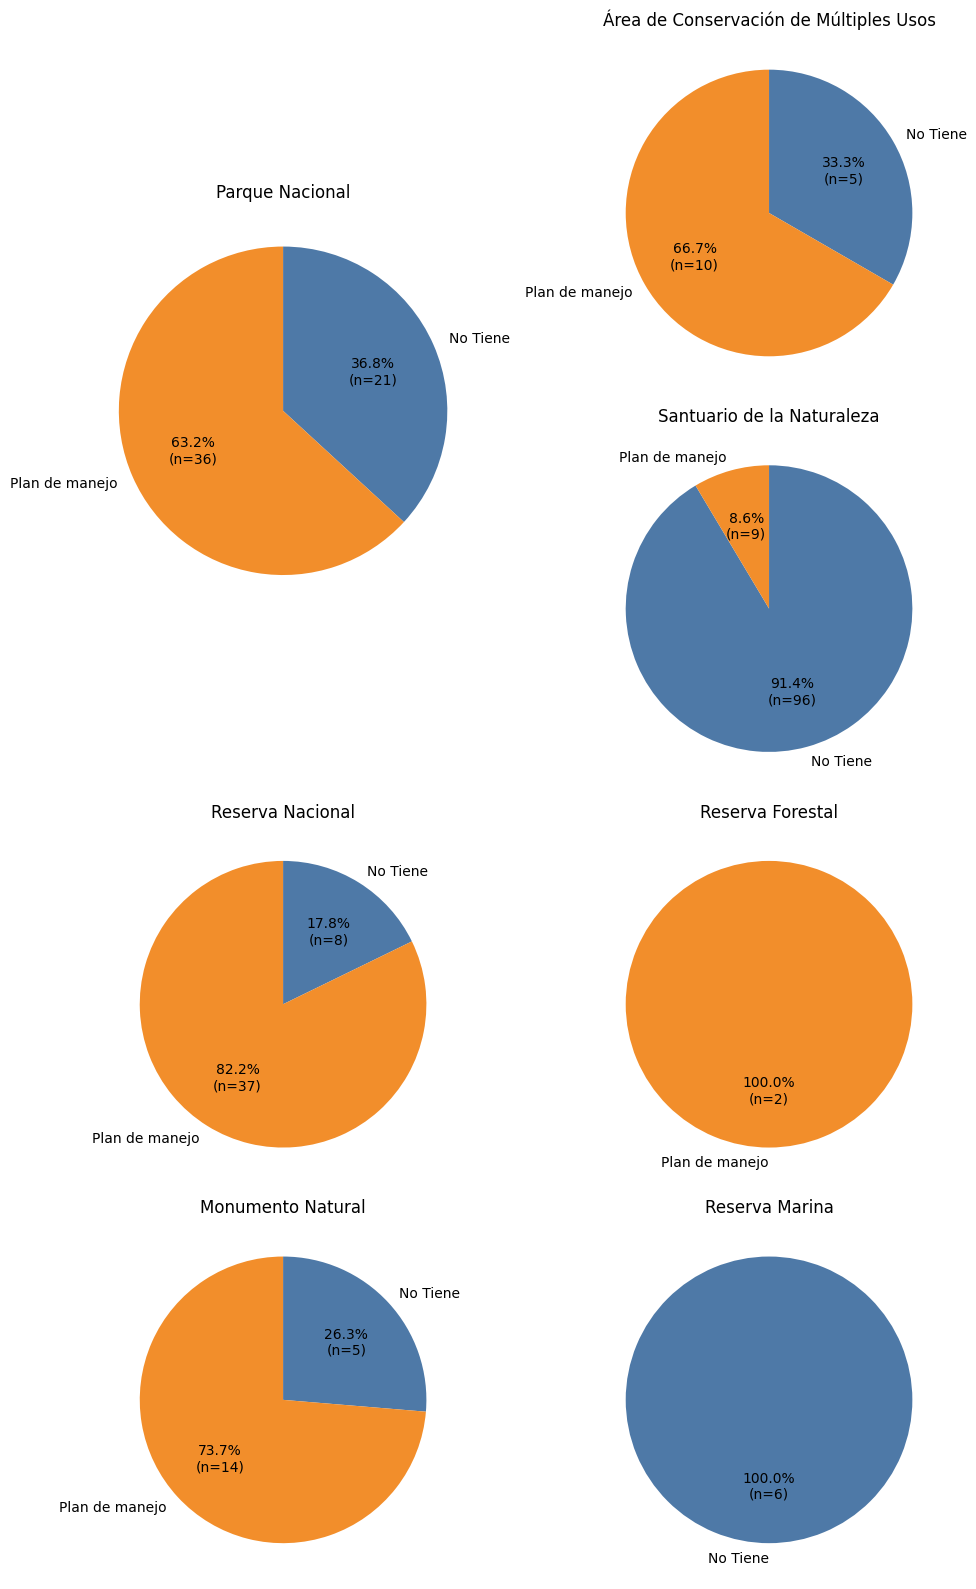

In [69]:
# Paleta fija por tipo de plan
COLOR_MAP = {
    "Plan de manejo": "#F28E2B",  # naranjo
    "No Tiene": "#4E79A7"         # azul
}

def pie_ax(ax, data, titulo):
    if data.empty:
        ax.axis("off")
        ax.set_title(f"{titulo}\n(sin datos)")
        return

    data = data.copy()
    data["color"] = data["tipo_plan"].map(COLOR_MAP)

    total = data["n"].sum()

    def autopct_fmt(pct):
        n = int(round(pct * total / 100))
        return f"{pct:.1f}%\n(n={n})"

    ax.pie(
        data["n"],
        labels=data["tipo_plan"],
        colors=data["color"],
        autopct=autopct_fmt,
        startangle=90,
        counterclock=False
    )
    ax.set_title(titulo)


# ============================================================
# Figura y layout
# ============================================================

fig = plt.figure(figsize=(10, 16))
gs = GridSpec(nrows=4, ncols=2, figure=fig)

# Parque Nacional: columna 0, filas 0–1
ax_parque = fig.add_subplot(gs[0:2, 0])
data_parque = tabla_n[tabla_n[CAT_COL] == "Parque Nacional"]
pie_ax(ax_parque, data_parque, "Parque Nacional")

# Otras categorías
cat_others = {
    (2, 0): "Reserva Nacional",
    (3, 0): "Monumento Natural",
    (0, 1): "Área de Conservación de Múltiples Usos",
    (1, 1): "Santuario de la Naturaleza",
    (2, 1): "Reserva Forestal",
    (3, 1): "Reserva Marina"
}

for (row, col), categoria in cat_others.items():
    ax = fig.add_subplot(gs[row, col])
    data = tabla_n[tabla_n[CAT_COL] == categoria]

    if not data.empty:
        pie_ax(ax, data, categoria)
    else:
        ax.axis("off")
        ax.set_title(f"{categoria}\n(sin datos)")

plt.tight_layout()
plt.show()
